This notebook contains training a neural network for additional current with which we try to match the recording from a single-compartment PASSIVE model to the multi-compartment one.

U is defined stepwise, not governed by a neural ODE.

Here we use the normalized voltage, u, and normalized time as input to the neural network.

In [1]:
import sys
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

%load_ext autoreload
%autoreload 2


from jax import config
config.update("jax_enable_x64", True)



import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import optax
from copy import deepcopy


import equinox as eqx
import flax.nnx as nnx


In [2]:
t_max = 200.0
setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"

cut = 0


# Define target
from voltage_fitting.build_simulator import (
    setup_passive_simulator,
    get_experimental_data,
    build_passive_cell,
    set_setup,
)

t, x_o, i_amp = get_experimental_data(setup, cut, t_max)
all_setup = set_setup(setup)
cell = build_passive_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup["capacitance"], all_setup["eleak"], all_setup["gleak"])

simulate_multi = setup_passive_simulator(cell, t_max, all_setup["v_init"], i_amp)

v_multi = simulate_multi()

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [3]:
#Define the cell
from voltage_fitting.single_build_simulator import (
    setup_passive_simulator,
    setup_passive_simulator_step,
    build_passive_cell,
    set_setup,
)

all_setup = set_setup(setup)
cell = build_passive_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

simulate_single = setup_passive_simulator(cell, t_max, all_setup["v_init"], i_amp)

v_single = simulate_single(x_o)[0]


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [4]:
# Define the networks
@jax.jit
def normalize_voltage(v):
    # Normalize voltage between -1 and 1
    return 2 * (v - jnp.min(v_multi)) / (jnp.max(v_multi) - jnp.min(v_multi)) - 1

class SimpleNeuralNet(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8):
        self.linear1 = nnx.Linear(u_dimension + 2, 32, rngs=rngs)
        #self.norm1 = nnx.LayerNorm(8, use_bias=True, use_scale=True, rngs = rngs)

        self.linear2 = nnx.Linear(32, 16, rngs=rngs)
        #self.norm2 = nnx.LayerNorm(8, use_bias=True, use_scale=True, rngs = rngs)

        self.linear3 = nnx.Linear(16, u_dimension, rngs=rngs)

    def __call__(self, inputs):
        x = self.linear1(inputs)
        x = jax.nn.relu(x)

        x = self.linear2(x)
        x = jax.nn.relu(x)
        return self.linear3(x)

class ReadoutNet(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8):
        self.linear1 = nnx.Linear(u_dimension, 32, rngs=rngs)
        self.linear2 = nnx.Linear(32, 1, rngs=rngs)

    def __call__(self, u):
        u = self.linear1(u)
        u = jax.nn.relu(u)
        return self.linear2(u)
    
class CorrectionModel(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8):
        self.neural_net = SimpleNeuralNet(rngs=rngs, u_dimension = u_dimension)
        self.readout_net = ReadoutNet(rngs=rngs, u_dimension = u_dimension)

    def __call__(self, u, v):
        u_new = self.neural_net(jnp.stack([u, v]))
        return self.readout_net(u_new)

In [5]:
def simulate_full_trace(neural_net, readout_net, initial_state, step_fn, current, time_vec, u_init):
    def cond_fn(carry):
        t, _, _, _ = carry
        return t < len(time_vec)

    def body_fn(carry):
        t, state, u, recs_adds = carry

        voltage = state["v"].squeeze()
        voltage_normalized = normalize_voltage(voltage)
        t_nn = t / 2500 - 1.0 #3500

        # We use the normalized voltage, the previous u and the normalized time value as input
        inputs = jnp.concatenate([jnp.expand_dims(voltage_normalized, 0), u, jnp.asarray([t_nn])], axis=0)

        u_new = neural_net(inputs)
        add_current = readout_net(u_new).squeeze()

        total_current = current[t] + add_current / 20. #10
        state, rec = step_fn(state, total_current)

        rec_voltage = rec[0]

        new_recs, new_adds = recs_adds
        new_recs = new_recs.at[t].set(rec_voltage)
        new_adds = new_adds.at[t].set(add_current)

        return (t + 1, state, u_new.squeeze(), (new_recs, new_adds))

    # Initialize buffers
    recs = jnp.full((len(time_vec),), jnp.nan)
    adds = jnp.full((len(time_vec),), jnp.nan)

    carry = (0, initial_state, u_init.squeeze(), (recs, adds))

    final_carry = eqx.internal.while_loop(
        cond_fun=cond_fn,
        body_fun=body_fn,
        init_val=carry,
        max_steps=len(time_vec),
        kind="bounded"
    )

    _, _, _, (recs, adds) = final_carry

    return recs, adds

In [6]:
def loss_fn(model, initial_state, step_fn, current, time_vec, u_init, v_multi, reg_strength=0.0):
    preds, additional_currents = simulate_full_trace(
        model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init
    )

    preds = preds.squeeze()
    v_multi = v_multi.squeeze()

    sse_loss = jnp.sum((preds - v_multi) ** 2)
    reg_loss = reg_strength * jnp.sum(jnp.abs(additional_currents))
    
    total_loss = sse_loss + reg_loss
    return total_loss

In [17]:
rngs = nnx.Rngs(1)
u_dimension = 8
np.random.seed(42)

u_init = jnp.asarray(np.random.randn(u_dimension))  # Initial hidden state of the neural network
model = CorrectionModel(rngs = rngs, u_dimension = u_dimension)

# Setup simulator
all_setup = set_setup(setup)
cell = build_passive_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
initial_state, step_fn, current, time_vec = setup_passive_simulator_step(cell, t_max, all_setup["v_init"], i_amp)

initial_lr = 15e-3 #lbfgs: 5e-1

# Exponential decay
decay_factor = 0.99
transition_steps = 1  # decay after every epoch
decay_until = 450  # after x epochs, stop decaying

# Normal exponential decay schedule
raw_schedule = optax.exponential_decay(
    init_value=initial_lr,
    transition_steps=transition_steps,
    decay_rate=decay_factor,
    staircase=True,
)

# Wrapped schedule that stops decaying after decay_until
def clipped_schedule(step):
    clipped_step = jnp.minimum(step, decay_until)
    return raw_schedule(clipped_step)

optimizer = optax.adam(learning_rate=clipped_schedule)
# Other optimizers tried:
# optimizer = optax.sgd(learning_rate=clipped_schedule, momentum = 0.7)
# optimizer = optax.chain(
#     optax.clip_by_global_norm(1e6),  # Clip gradients
#     optax.sgd(learning_rate=clipped_schedule, momentum=0.5)
# )

# optimizer = optax.chain(
#     optax.scale_by_lbfgs(memory_size = 5), #32: 10
#     optax.scale(-initial_lr),
# )
optimizer_state = nnx.Optimizer(model, optimizer)


def simulation_loss_fn(model):
        loss = loss_fn(model, initial_state, step_fn, current, time_vec, u_init, v_multi)
        return loss


num_epochs = 500
losses = []

grad_fn = nnx.jit(nnx.value_and_grad(simulation_loss_fn))

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [18]:
for epoch in range(num_epochs):

    loss, grads = grad_fn(optimizer_state.model)
    optimizer_state.update(grads)

    # inter_ts, inter_us, inter_preds, inter_additional_currents = simulate_full_trace(
    # model.neural_net,
    # model.readout_net,
    # initial_state,
    # step_fn,
    # current,
    # time_vec,
    # u_init
    # )
    

    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")
        if epoch == 200:
            model_200 = deepcopy(model)
        # print(f"Min added current: {jnp.min(inter_additional_currents)}, max added current: {jnp.max(inter_additional_currents)}")
        # print(f"Min u: {jnp.min(inter_us)}, max u: {jnp.max(inter_us)}")
        # print(f"Min tnn: {jnp.min(inter_ts)}, max tnn: {jnp.max(inter_ts)}")
        # print("")

Epoch 0, Loss: 1018.208910
Epoch 10, Loss: 962.178168
Epoch 20, Loss: 535.840980
Epoch 30, Loss: 417.022455
Epoch 40, Loss: 306.632685
Epoch 50, Loss: 195.044111
Epoch 60, Loss: 214.630438
Epoch 70, Loss: 115.814414
Epoch 80, Loss: 55.663064
Epoch 90, Loss: 47.566789
Epoch 100, Loss: 33.752013
Epoch 110, Loss: 24.648837
Epoch 120, Loss: 18.452005
Epoch 130, Loss: 35.128012
Epoch 140, Loss: 14.362093
Epoch 150, Loss: 13.716524
Epoch 160, Loss: 10.469623
Epoch 170, Loss: 9.642691
Epoch 180, Loss: 8.705534
Epoch 190, Loss: 8.029656
Epoch 200, Loss: 7.538548
Epoch 210, Loss: 7.189543
Epoch 220, Loss: 6.939974
Epoch 230, Loss: 6.755588
Epoch 240, Loss: 6.610427
Epoch 250, Loss: 6.486300
Epoch 260, Loss: 6.381019
Epoch 270, Loss: 6.287103
Epoch 280, Loss: 6.197119
Epoch 290, Loss: 6.105047
Epoch 300, Loss: 6.019751
Epoch 310, Loss: 5.948883
Epoch 320, Loss: 5.890504
Epoch 330, Loss: 5.841122
Epoch 340, Loss: 5.797365
Epoch 350, Loss: 5.758079
Epoch 360, Loss: 5.722800
Epoch 370, Loss: 5.6917

Results:

In [9]:
final_preds, final_additional_currents = simulate_full_trace(
    model.neural_net,
    model.readout_net,
    initial_state,
    step_fn,
    current,
    time_vec,
    u_init
)


final_sse_loss = jnp.sum((final_preds.squeeze() - v_multi.squeeze())**2)
final_reg_loss = jnp.sum(final_additional_currents)

In [10]:
print("Final SSE loss: ", final_sse_loss, ", Final regulation loss: ", final_reg_loss)

Final SSE loss:  5.464771897895451 , Final regulation loss:  154.05713333651698


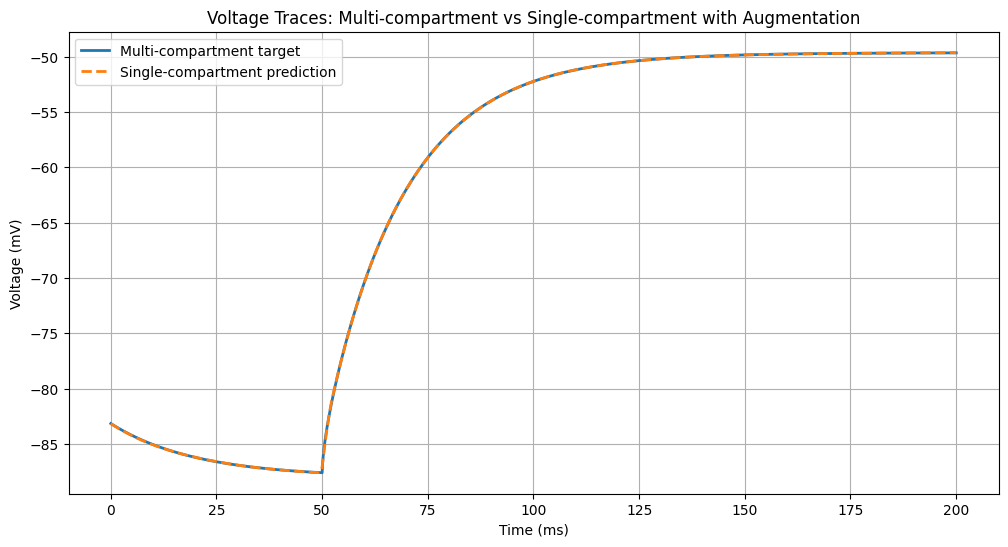

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(time_vec, v_multi[0], label="Multi-compartment target", linewidth=2)
plt.plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Voltage Traces: Multi-compartment vs Single-compartment with Augmentation")
plt.grid()

plt.show()

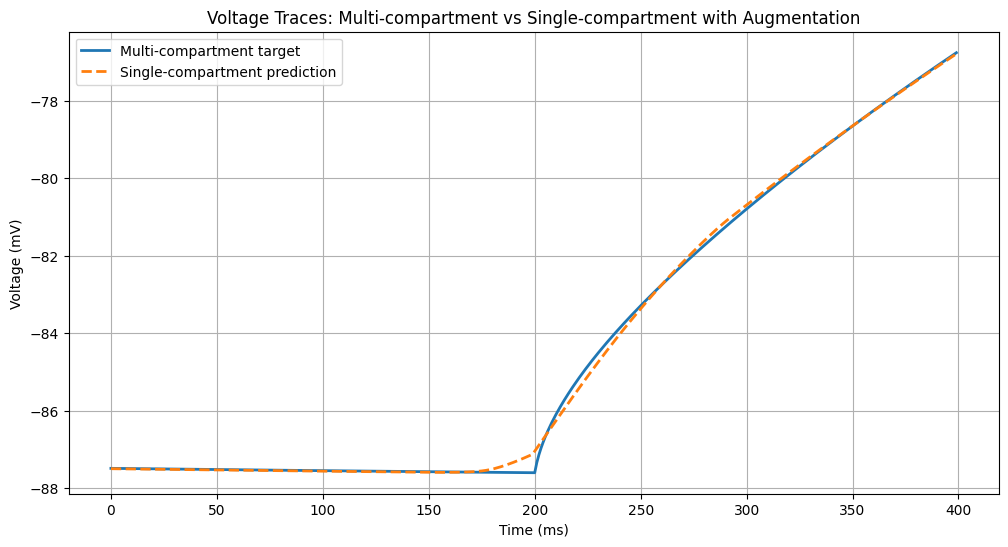

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(v_multi[0][1800:2200], label="Multi-compartment target", linewidth=2)
plt.plot(final_preds[1800:2200], label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Voltage Traces: Multi-compartment vs Single-compartment with Augmentation")
plt.grid()

plt.show()

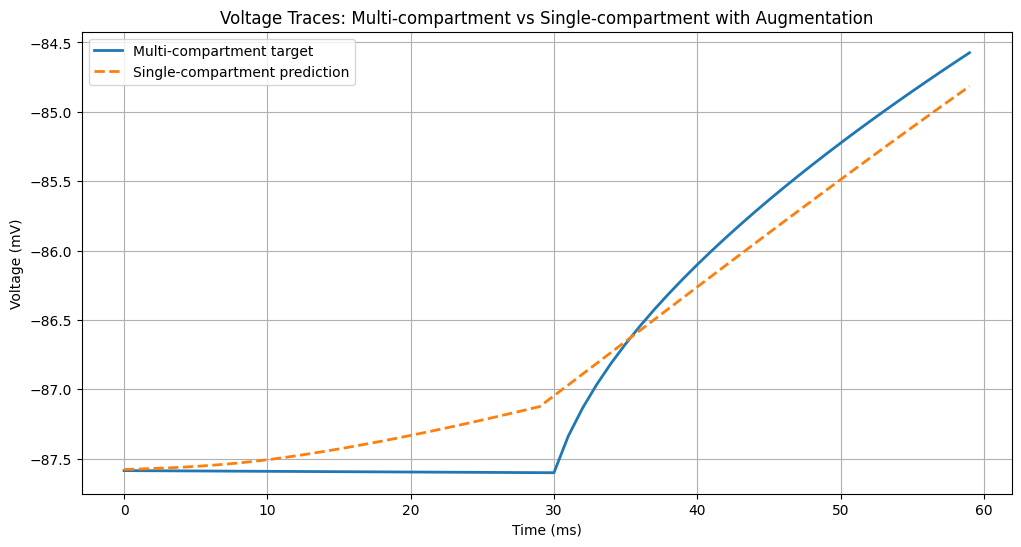

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(v_multi[0][1970:2030], label="Multi-compartment target", linewidth=2)
plt.plot(final_preds[1970:2030], label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Voltage Traces: Multi-compartment vs Single-compartment with Augmentation")
plt.grid()

plt.show()

Text(0.5, 1.0, 'Additional current (mV)')

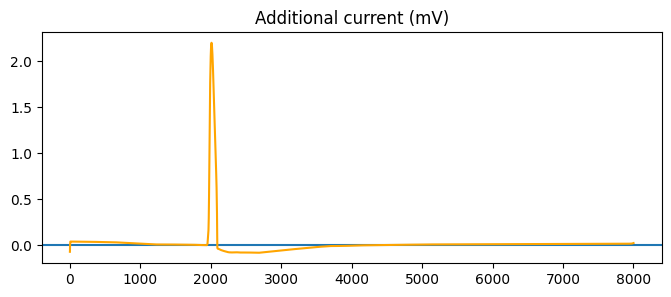

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
_ = ax.axhline(0.0)
_ = ax.plot(final_additional_currents, color = "orange")
ax.set_title("Additional current (mV)")

In [44]:
np.save("../results/with_t_final_preds.npy", final_preds)
np.save("../results/with_t_final_additional_currents.npy", final_additional_currents)
np.save("../results/with_t_losses.npy", losses)

Results after 200 epochs:

In [19]:
final_preds, final_additional_currents = simulate_full_trace(
    model_200.neural_net,
    model_200.readout_net,
    initial_state,
    step_fn,
    current,
    time_vec,
    u_init
)


final_sse_loss = jnp.sum((final_preds.squeeze() - v_multi.squeeze())**2)
final_reg_loss = jnp.sum(final_additional_currents)

In [20]:
print("Final SSE loss: ", final_sse_loss, ", Final regulation loss: ", final_reg_loss)

Final SSE loss:  7.491175223524173 , Final regulation loss:  154.2407462862282


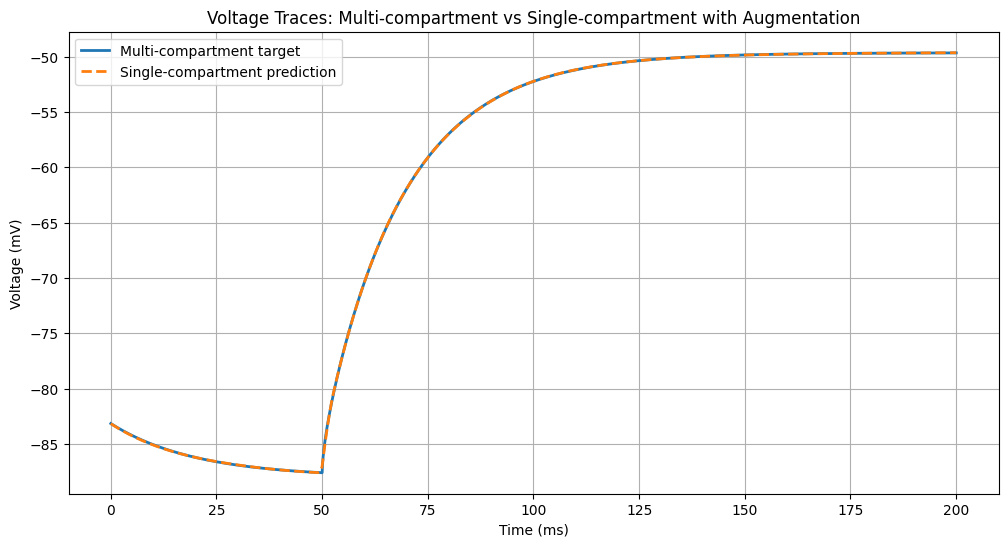

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(time_vec, v_multi[0], label="Multi-compartment target", linewidth=2)
plt.plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Voltage Traces: Multi-compartment vs Single-compartment with Augmentation")
plt.grid()

plt.show()

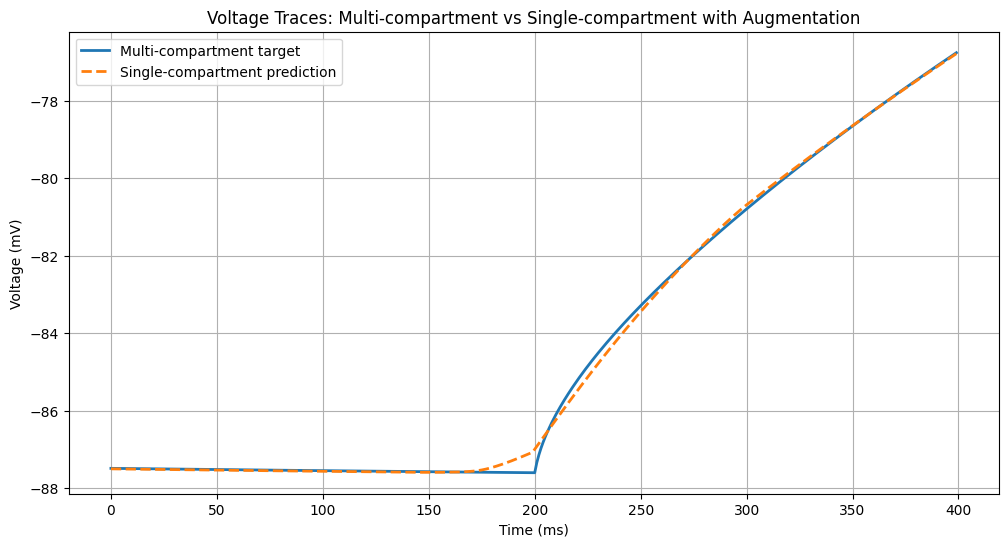

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(v_multi[0][1800:2200], label="Multi-compartment target", linewidth=2)
plt.plot(final_preds[1800:2200], label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Voltage Traces: Multi-compartment vs Single-compartment with Augmentation")
plt.grid()

plt.show()

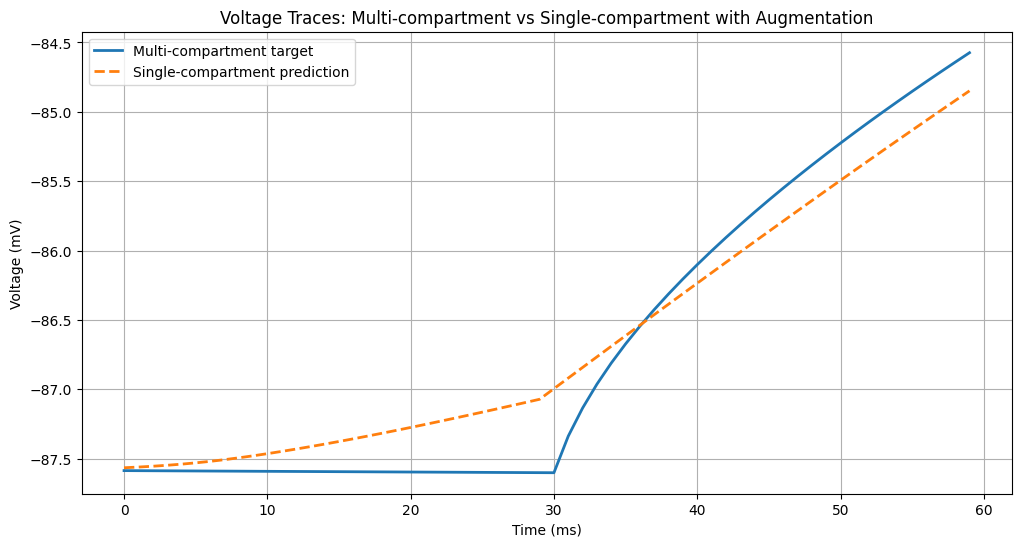

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(v_multi[0][1970:2030], label="Multi-compartment target", linewidth=2)
plt.plot(final_preds[1970:2030], label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Voltage Traces: Multi-compartment vs Single-compartment with Augmentation")
plt.grid()

plt.show()

Text(0.5, 1.0, 'Additional current (mV)')

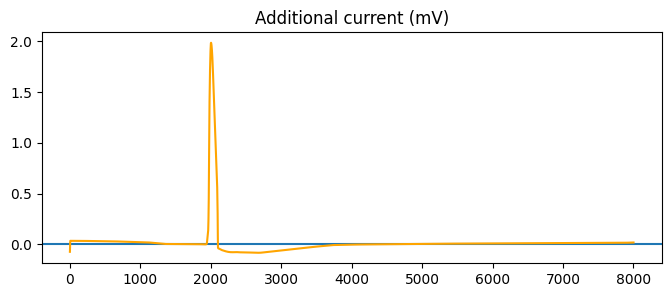

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
_ = ax.axhline(0.0)
_ = ax.plot(final_additional_currents, color = "orange")
ax.set_title("Additional current (mV)")

In [43]:
np.save("../results/with_t_final_preds_200.npy", final_preds)
np.save("../results/with_t_final_additional_currents_200.npy", final_additional_currents)